<a href="https://colab.research.google.com/github/yeshaa23/ZARA-AppsReview-SentimentAnalysis/blob/main/Week%204/TF-IDF/ZARA_Google_App_Review_TFIDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ZARA Google Play Review - TF-IDF

##Install dan Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
pip install -U nltk

In [3]:
pip install tensorflow_hub

In [4]:
pip install torch

In [5]:
pip install xgboost

In [6]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
import torch
import tensorflow as tf
import tensorflow_hub as hub

In [7]:
from collections import Counter
from timeit import default_timer as timer

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from timeit import default_timer as timer

from scipy.sparse import vstack, hstack, csr_matrix
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('words')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
stop_words = set(stopwords.words('english'))

## Cek device (GPU)

In [9]:
is_cuda = torch.cuda.is_available()

# If we have a GPU available, we'll set our device to GPU.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")

GPU not available, CPU used


## Load Dataset

In [10]:
df = pd.read_csv('/content/drive/My Drive/Tugas-1A-PBA/text_preprocessed_review_zara.csv')
print(f'Total data awal: {df.shape[0]:,} baris | {df.shape[1]} kolom')
print('Kolom yang tersedia:', list(df.columns))

Total data awal: 13,139 baris | 14 kolom
Kolom yang tersedia: ['id', 'score', 'at', 'review', 'language', 'sentiment_rating', 'review_original', 'token', 'token_after_sr', 'cleaned_content', 'token_after_lemma', 'token_after_stem', 'sentiment_polarity', 'sentiment_subjective']


## Exploratory Data Analysis

In [11]:
# Deteksi kolom teks dan label
possible_text_cols = ['review', 'content', 'final_text', 'cleaned_content', 'text']
possible_label_cols = ['sentiment_rating', 'sentiment', 'label', 'sentiment_label']

text_col = next((col for col in possible_text_cols if col in df.columns), None)
label_col = next((col for col in possible_label_cols if col in df.columns), None)

if text_col is None:
    raise ValueError("Kolom teks tidak ditemukan. Pastikan ada salah satu dari: review, content, final_text, cleaned_content, text")

if label_col is None:
    raise ValueError("Kolom label tidak ditemukan. Pastikan ada salah satu dari: sentiment_rating, sentiment, label, sentiment_label")

print(f'Kolom teks  : {text_col}')
print(f'Kolom label : {label_col}')

Kolom teks  : review
Kolom label : sentiment_rating


In [12]:
# Normalisasi label
def normalize_label(x):
    x = str(x).strip().lower()
    mapping = {
        'negative': 'negative',
        'negatif': 'negative',
        '0': 'negative',

        'neutral': 'neutral',
        'netral': 'neutral',
        '1': 'neutral',

        'positive': 'positive',
        'positif': 'positive',
        '2': 'positive'
    }
    return mapping.get(x, x)

df[label_col] = df[label_col].apply(normalize_label)

valid_labels = {'negative', 'neutral', 'positive'}
df = df[df[label_col].isin(valid_labels)].copy()

print('\nDistribusi label setelah normalisasi:')
print(df[label_col].value_counts())


Distribusi label setelah normalisasi:
sentiment_rating
negative    6450
positive    5748
neutral      941
Name: count, dtype: int64


In [13]:
# EDA Class
class EDA:
    def get_length_dist(self, data):
        rev_len = [len(str(i)) for i in data]

        plt.figure(figsize=(8, 4))
        plt.hist(
            rev_len,
            bins=30,
            color='#CDB4DB',
            edgecolor='white'
        )
        plt.title('Distribusi Panjang Review', fontsize=12, fontweight='bold')
        plt.xlabel('Jumlah karakter')
        plt.ylabel('Frekuensi')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        print(pd.Series(rev_len).describe())


    def get_class_dist(self, df, label_col):
        counts = df[label_col].value_counts()
        color_map = {
            'positive': '#B7E4C7',
            'negative': '#F4A7A3',
            'neutral':  '#A8D0F0'
        }

        colors = [color_map.get(lbl, '#CCCCCC') for lbl in counts.index]

        plt.figure(figsize=(7, 4))
        bars = plt.bar(
            counts.index,
            counts.values,
            color=colors,
            edgecolor='white'
        )

        plt.title('Distribusi Kelas Sentimen', fontsize=12, fontweight='bold')
        plt.xlabel('Sentimen')
        plt.ylabel('Jumlah Review')
        plt.grid(axis='y', linestyle='--', alpha=0.5)

        for bar, val in zip(bars, counts.values):
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts.values)*0.01,
                f'{val:,}',
                ha='center',
                fontsize=10,
                fontweight='bold'
            )

        plt.tight_layout()
        plt.show()

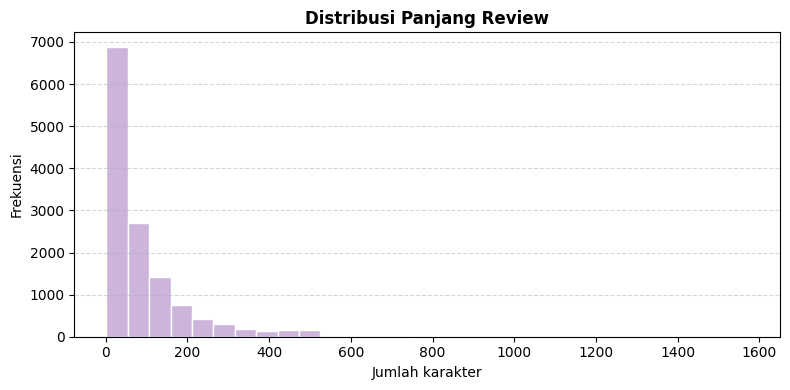

count    13139.000000
mean        89.165309
std        101.587074
min          2.000000
25%         24.000000
50%         51.000000
75%        114.000000
max       1572.000000
dtype: float64


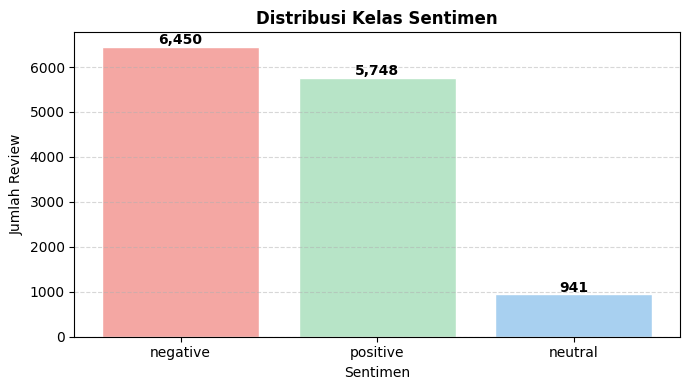

In [14]:
eda = EDA()
eda.get_length_dist(df[text_col])
eda.get_class_dist(df, label_col)

## Preprocessing Data

In [15]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text)
    # hapus HTML
    text = re.sub(r'<[^>]*>', '', text)
    # strip whitespace
    text = text.strip()
    # lowercase
    text = text.lower()
    # hapus karakter aneh selain huruf/angka/spasi
    text = re.sub(r'[^\w\s]', ' ', text)
    # rapikan spasi
    text = re.sub(r'\s+', ' ', text)
    # tokenisasi
    words = word_tokenize(text)
    # remove stopwords
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [16]:
df['final_text'] = df[text_col].astype(str).apply(preprocess_text)

In [17]:
df['final_text'].head(20)

,final_text
0,everytime try use app starts update believe gu...
1,smooth online purchase
2,easy app use
3,great service thanks
4,website nightmare make payment
5,app hard navigate time newest update use black...
6,love app zara amazing
7,app working deleted old account create new acc...
8,problem login app
9,great app


In [18]:
print('Contoh hasil preprocessing:')
print(df[[text_col, 'final_text', label_col]].head())

Contoh hasil preprocessing:
                                              review  \
0  everytime i try to use it the app starts to up...   
1                             smooth online purchase   
2                                    easy app to use   
3                               great service thanks   
4              website a nightmare to make a payment   

                                          final_text sentiment_rating  
0  everytime try use app starts update believe gu...         negative  
1                             smooth online purchase         positive  
2                                       easy app use         positive  
3                               great service thanks         positive  
4                     website nightmare make payment         negative  


## Analisis Class Imbalance

In [19]:
print('\nDistribusi sentimen full dataset:')
print(df[label_col].value_counts())
print('\nProporsi kelas:')
print(df[label_col].value_counts(normalize=True).round(4))


Distribusi sentimen full dataset:
sentiment_rating
negative    6450
positive    5748
neutral      941
Name: count, dtype: int64

Proporsi kelas:
sentiment_rating
negative    0.4909
positive    0.4375
neutral     0.0716
Name: proportion, dtype: float64


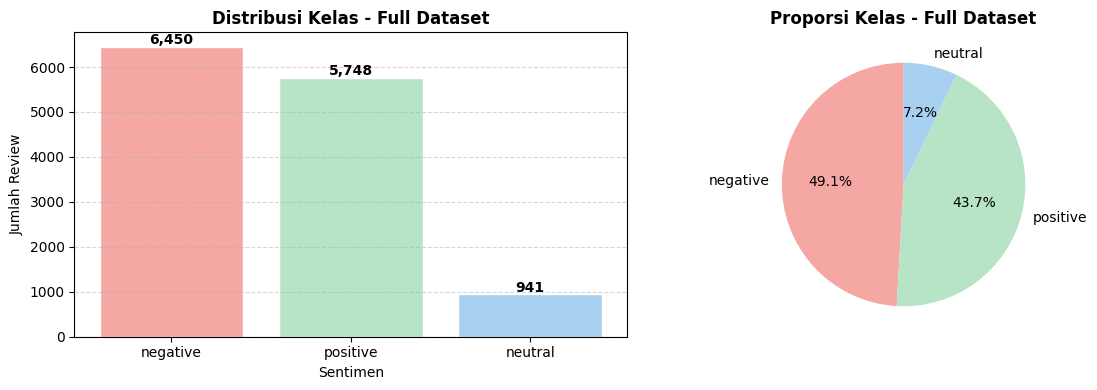

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sentiment_counts = df[label_col].value_counts()
sentiment_labels = sentiment_counts.index.tolist()
color_map = {
    'positive': '#B7E4C7',
    'negative': '#F4A7A3',
    'neutral':  '#A8D0F0'
}

colors = [color_map.get(str(lbl).lower(), '#CCCCCC') for lbl in sentiment_labels]

# bar chart
axes[0].bar(
    sentiment_labels,
    sentiment_counts.values,
    color=colors,
    edgecolor='white'
)

axes[0].set_title('Distribusi Kelas - Full Dataset', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Review')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, (lbl, val) in enumerate(sentiment_counts.items()):
    axes[0].text(
        i,
        val + max(sentiment_counts.values)*0.01,
        f'{val:,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# pie chart
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)

axes[1].set_title('Proporsi Kelas - Full Dataset', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
df_valid = df[
    df['final_text'].notna() &
    (df['final_text'].astype(str).str.strip() != '')
].copy()

print(f'Data valid yang dipakai: {len(df_valid):,} dari {len(df):,}')

Data valid yang dipakai: 13,129 dari 13,139


## Wordcloud

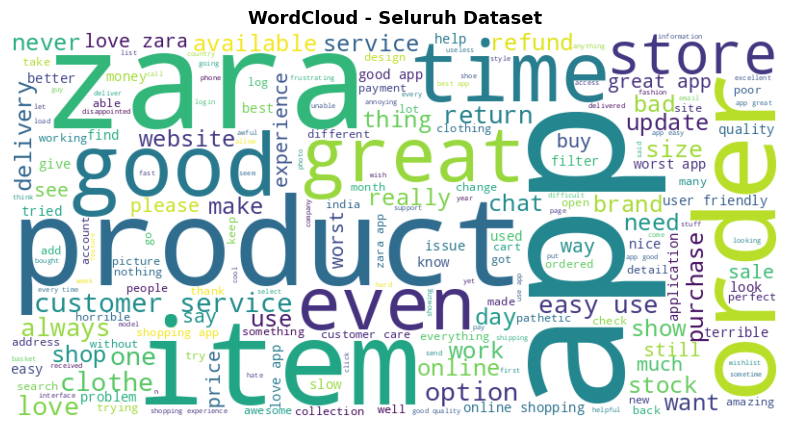

In [22]:
from wordcloud import WordCloud

all_text = ' '.join(df['final_text'].astype(str))

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'  # bisa ganti 'cool', 'plasma', dll
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Seluruh Dataset', fontsize=13, fontweight='bold')
plt.show()

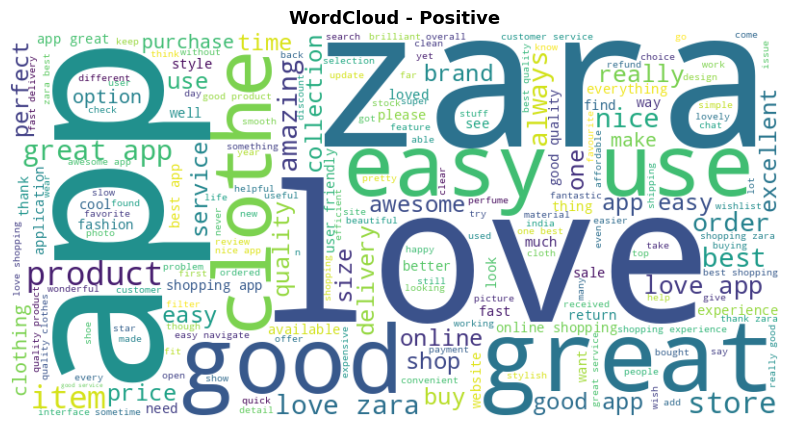

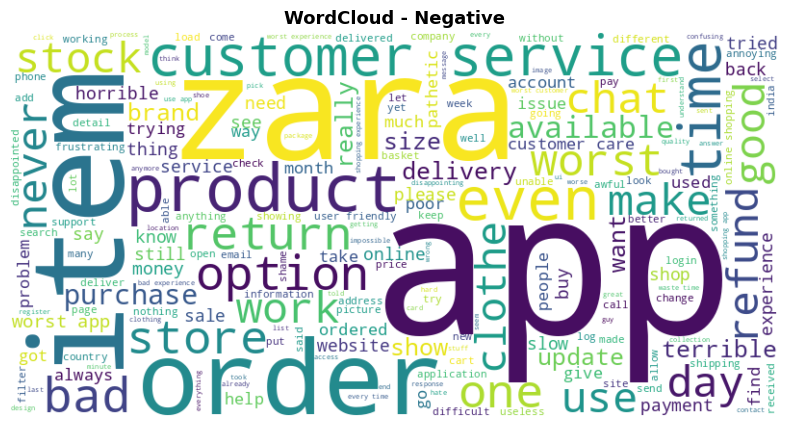

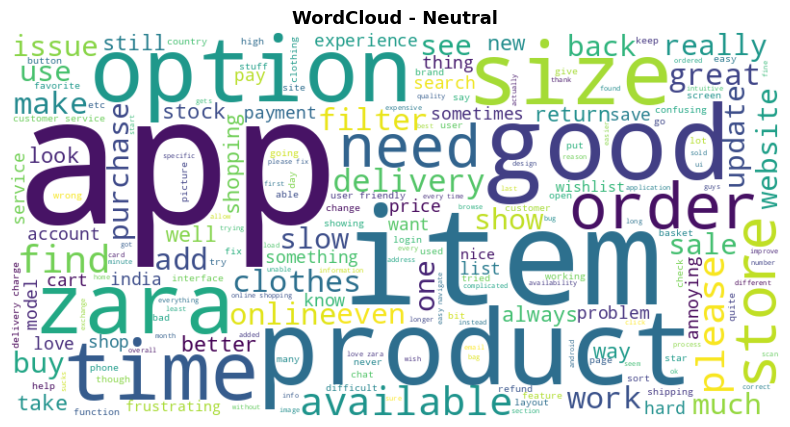

In [23]:
# wordcloud per sentimen
for label in ['positive', 'negative', 'neutral']:
    text = ' '.join(df[df[label_col] == label]['final_text'].astype(str))

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud - {label.capitalize()}', fontsize=13, fontweight='bold')
    plt.show()

##Label Encoding

In [24]:
label_encode = LabelEncoder()
Y_encoded = label_encode.fit_transform(df_valid[label_col])

CLASS_NAMES = list(label_encode.classes_)
print(f'Label Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')

x_data = df_valid['final_text'].astype(str)
y_data = Y_encoded

xtrain, xtest, ytrain, ytest = train_test_split(
    x_data, y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

Label Mapping: ['negative', 'neutral', 'positive'] -> [0 1 2]


In [25]:
print(f'Training set : {len(xtrain):,}')
print(f'Testing set  : {len(xtest):,}')

for split_name, y_split in [('Train', ytrain), ('Test', ytest)]:
    print(f'\n{split_name} distribution:')
    counts = pd.Series(y_split).value_counts().sort_index()
    for idx, cnt in counts.items():
        print(f'  {CLASS_NAMES[idx]:<10}: {cnt:,} ({cnt/len(y_split)*100:.1f}%)')

Training set : 10,503
Testing set  : 2,626

Train distribution:
  negative  : 5,157 (49.1%)
  neutral   : 752 (7.2%)
  positive  : 4,594 (43.7%)

Test distribution:
  negative  : 1,290 (49.1%)
  neutral   : 188 (7.2%)
  positive  : 1,148 (43.7%)


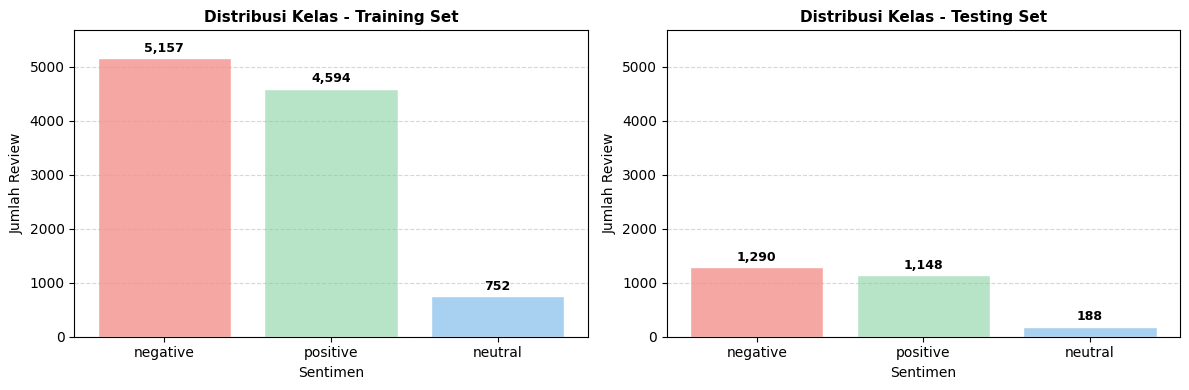

In [26]:
train_counts = pd.Series(ytrain).map(dict(enumerate(CLASS_NAMES))).value_counts()
test_counts  = pd.Series(ytest).map(dict(enumerate(CLASS_NAMES))).value_counts()

# visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
max_y = max(train_counts.max(), test_counts.max()) * 1.1
color_map = {
    'positive': '#B7E4C7',
    'negative': '#F4A7A3',
    'neutral':  '#A8D0F0'
}

for ax, data, title in zip(
    axes,
    [train_counts, test_counts],
    ['Distribusi Kelas - Training Set', 'Distribusi Kelas - Testing Set']
):
    labels_now = data.index.tolist()
    colors_now = [color_map.get(str(lbl).lower(), '#CCCCCC') for lbl in labels_now]

    bars = ax.bar(
        labels_now,
        data.values,
        color=colors_now,
        edgecolor='white'
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Sentimen')
    ax.set_ylabel('Jumlah Review')
    ax.set_ylim(0, max_y)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    for bar, val in zip(bars, data.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + max_y*0.02,
            f'{val:,}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )
plt.tight_layout()
plt.show()

##Create Vocabulary

In [27]:
# Create a vocabulary
from collections import Counter
word_counts = Counter(' '.join(str(t) for t in xtrain).split())
print(f'Total kata unik: {len(word_counts):,}')

Total kata unik: 8,731


In [28]:
# Display vocabulary dan count nya
print('\n50 kata paling sering:')
for word, count in word_counts.most_common(50):
    print(f'  {word}: {count:,}')


50 kata paling sering:
  app: 3,862
  zara: 1,646
  good: 966
  love: 942
  order: 810
  great: 796
  service: 793
  easy: 763
  customer: 730
  shopping: 715
  use: 709
  items: 705
  online: 664
  time: 643
  worst: 632
  like: 562
  experience: 543
  clothes: 536
  delivery: 536
  product: 521
  even: 509
  store: 485
  one: 462
  bad: 446
  best: 446
  really: 441
  buy: 420
  quality: 416
  products: 407
  return: 403
  get: 399
  item: 380
  ever: 365
  option: 345
  refund: 340
  please: 331
  would: 331
  never: 325
  always: 325
  brand: 324
  available: 323
  shop: 320
  back: 308
  also: 303
  user: 301
  update: 299
  stock: 299
  chat: 295
  size: 294
  account: 294


In [29]:
vocab = [word for word, count in word_counts.most_common()]
vocab

['app',
 'zara',
 'good',
 'love',
 'order',
 'great',
 'service',
 'easy',
 'customer',
 'shopping',
 'use',
 'items',
 'online',
 'time',
 'worst',
 'like',
 'experience',
 'clothes',
 'delivery',
 'product',
 'even',
 'store',
 'one',
 'bad',
 'best',
 'really',
 'buy',
 'quality',
 'products',
 'return',
 'get',
 'item',
 'ever',
 'option',
 'refund',
 'please',
 'would',
 'never',
 'always',
 'brand',
 'available',
 'shop',
 'back',
 'also',
 'user',
 'update',
 'stock',
 'chat',
 'size',
 'account',
 'find',
 'see',
 'purchase',
 'want',
 'go',
 'still',
 'much',
 'nice',
 'work',
 'days',
 'could',
 'new',
 'money',
 'make',
 'website',
 'friendly',
 'need',
 'slow',
 'add',
 'well',
 'better',
 'payment',
 'poor',
 'way',
 'clothing',
 'every',
 'got',
 'navigate',
 'anything',
 'terrible',
 'know',
 'working',
 'india',
 'times',
 'cart',
 'ordered',
 'tried',
 'many',
 'horrible',
 'received',
 'amazing',
 'shipping',
 'give',
 'care',
 'support',
 'everything',
 'application

### Classification with various classifiers
#### 1. Linear SVM
#### 2. Logistic Regression (LR)
#### 3. Naive Bayes
#### 4. XGBoost
#### 5. Random Forest

In [30]:
# sample weight
sample_weights = compute_sample_weight(class_weight='balanced', y=ytrain)

print('Sample weight per kelas:')
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    w = sample_weights[ytrain == cls_idx][0]
    print(f'  {cls_name:<10}: {w:.4f}')

Sample weight per kelas:
  negative  : 0.6789
  neutral   : 4.6556
  positive  : 0.7621


## Initialize Classifiers

In [31]:
svm_classifier = LinearSVC()
logistic_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier()
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=0)

In [32]:
def evaluate_model(model, xtest, ytest):
    # Make predictions using the model
    y_pred = model.predict(xtest)

    # Calculate accuracy
    accuracy = accuracy_score(ytest, y_pred)
    # Calculate precision
    precision = precision_score(ytest, y_pred, average='weighted')
    # Calculate recall
    recall = recall_score(ytest, y_pred, average='weighted')
    # Calculate f1 score
    f1 = f1_score(ytest, y_pred, average='weighted')
    # Generate a classification report and confusion matrix
    report = classification_report(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [33]:
# Define batch size
batch_size = 1000

## TF-IDF

### TF-IDF Vectorization

In [34]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

### Process the data in smaller batches

In [35]:
# buat training data
start = timer()
tfidf_vectorizer_xtrain = []
for i in range(0, len(xtrain), batch_size):
    batch_X_train = xtrain[i:i + batch_size]
    batch_X_train_tfidf = tfidf_vectorizer.fit_transform(batch_X_train)
    tfidf_vectorizer_xtrain.extend(batch_X_train_tfidf.toarray())
print('Required time for embedding TFIDF with train data:- ', timer() - start)

Required time for embedding TFIDF with train data:-  0.6176308009999047


In [36]:
# buat test data
start = timer()
tfidf_vectorizer_xtest = []
for i in range(0, len(xtest), batch_size):
    batch_X_test = xtest[i:i + batch_size]
    batch_X_test_tfidf = tfidf_vectorizer.transform(batch_X_test)
    tfidf_vectorizer_xtest.extend(batch_X_test_tfidf.toarray())
print('Required time for embedding TFIDF with train data:- ', timer() - start)

Required time for embedding TFIDF with train data:-  0.19097424500023408


### Fit Classifier

In [37]:
start = timer()
# Fit the TfidfVectorizer on the entire training data
tfidf_vectorizer_xtrain = tfidf_vectorizer.fit_transform(xtrain)
print('Required time for embedding TFIDF with train data:- ', timer() - start)

start = timer()
# Transform the test data using the fitted vectorizer
tfidf_vectorizer_xtest = tfidf_vectorizer.transform(xtest)
print('Required time for embedding TFIDF with test data:- ', timer() - start)

# Convert the sparse matrices to dense arrays
tfidf_vectorizer_xtrain = tfidf_vectorizer_xtrain.toarray()
tfidf_vectorizer_xtest = tfidf_vectorizer_xtest.toarray()

# Fit the SVM classifier to the TF-IDF training data
svm_tfidf = svm_classifier.fit(tfidf_vectorizer_xtrain, ytrain) # This line is added

Required time for embedding TFIDF with train data:-  0.3630099449997033
Required time for embedding TFIDF with test data:-  0.05283336000002237


### Make Prediction

### Linear SVM

In [38]:
start = timer()
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, confusion_matrix_svm = evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for SVM prediction:- ', timer() - start)

Required time for SVM prediction:-  0.14970294600016132


In [39]:
#print actual vs predicted result for LinearSVM
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm[:15]):
    print(f"Actual: {actual}, SVM Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 2

Actual: 2, SVM Predicted: 2

Actual: 0, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 2, SVM Predicted: 2

Actual: 2, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 2, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 0, SVM Predicted: 0



In [40]:
print(f"LinearSVM Accuracy: {accuracy_svm:.2f}")
print(f"LinearSVM Precision: {precision_svm:.2f}")
print(f"LinearSVM Recall: {recall_svm:.2f}")
print(f"LinearSVM F1 score: {f1_svm:.2f}")
print("Classification Report:")
print(report_svm)
print("Confusion Matrix")
print(confusion_matrix_svm)

LinearSVM Accuracy: 0.83
LinearSVM Precision: 0.80
LinearSVM Recall: 0.83
LinearSVM F1 score: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1290
           1       0.32      0.09      0.13       188
           2       0.87      0.87      0.87      1148

    accuracy                           0.83      2626
   macro avg       0.67      0.62      0.62      2626
weighted avg       0.80      0.83      0.81      2626

Confusion Matrix
[[1170   25   95]
 [ 116   16   56]
 [ 143    9  996]]


### Logistic Regression

In [41]:
lr_tfidf = logistic_regression.fit(tfidf_vectorizer_xtrain, ytrain)

In [42]:
start = timer()
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = evaluate_model(lr_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Logistic Regression prediction:- ', timer() - start)

Required time for Logistic Regression prediction:-  0.09516957200003162


In [43]:
# print actual vs predicted results for Logistic Regression
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 2

Actual: 2, Logistic Regression Predicted: 2

Actual: 0, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 2, Logistic Regression Predicted: 2

Actual: 2, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 2, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 0, Logistic Regression Predicted: 0



In [44]:
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")
print(f"Logistic Regression Precision: {precision_lr:.2f}")
print(f"Logistic Regression Recall: {recall_lr:.2f}")
print(f"Logistic Regression F1 score: {f1_lr:.2f}")
print("Classification Report:")
print(report_lr)
print("Confusion Matrix")
print(cm_lr)

Logistic Regression Accuracy: 0.84
Logistic Regression Precision: 0.80
Logistic Regression Recall: 0.84
Logistic Regression F1 score: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.87      1290
           1       0.20      0.01      0.02       188
           2       0.89      0.85      0.87      1148

    accuracy                           0.84      2626
   macro avg       0.63      0.60      0.59      2626
weighted avg       0.80      0.84      0.81      2626

Confusion Matrix
[[1216    4   70]
 [ 135    2   51]
 [ 165    4  979]]


### Naive Bayes

In [45]:
nb_tfidf = nb_classifier.fit(tfidf_vectorizer_xtrain, ytrain)

In [46]:
start = timer()
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Naive Bayes prediction:- ', timer() - start)

Required time for Naive Bayes prediction:-  0.052665886000340834


In [47]:
# print actual vs predicted results for Naive Bayes
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_nb[:15]):
    print(f"Actual: {actual}, Naive bayes Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 2

Actual: 2, Naive bayes Predicted: 2

Actual: 0, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 2, Naive bayes Predicted: 2

Actual: 2, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 2, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 0, Naive bayes Predicted: 0



In [48]:
print(f"Naive bayes Accuracy: {accuracy_nb:.2f}")
print(f"Naive bayes Precision: {precision_nb:.2f}")
print(f"Naive bayes Recall: {recall_nb:.2f}")
print(f"Naive bayes F1 score: {f1_nb:.2f}")
print("Classification Report:")
print(report_nb)
print("Confusion Matrix:")
print(cm_nb)

Naive bayes Accuracy: 0.83
Naive bayes Precision: 0.77
Naive bayes Recall: 0.83
Naive bayes F1 score: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85      1290
           1       0.00      0.00      0.00       188
           2       0.87      0.85      0.86      1148

    accuracy                           0.83      2626
   macro avg       0.55      0.59      0.57      2626
weighted avg       0.77      0.83      0.79      2626

Confusion Matrix:
[[1189    0  101]
 [ 139    0   49]
 [ 170    0  978]]


### XGBoost Classifier

In [49]:
xgboost_tfidf = xgboost_classifier.fit(tfidf_vectorizer_xtrain, ytrain)

In [50]:
start = timer()
y_pred_xgboost, accuracy_xgboost, precision_xgboost, recall_xgboost, f1_xgboost, report_xgboost, cm_xgboost = evaluate_model(xgboost_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for XGBoost classifier prediction:- ', timer() - start)

Required time for XGBoost classifier prediction:-  0.12666360699995494


In [51]:
#  print actual vs predicted results for XGBoost classifier
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost[:15]):
    print(f"Actual: {actual}, XGBoost Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 2

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 2

Actual: 2, XGBoost Predicted: 2

Actual: 0, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 2

Actual: 2, XGBoost Predicted: 2

Actual: 2, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 2

Actual: 2, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 2

Actual: 0, XGBoost Predicted: 0



In [52]:
print(f"XGBoost Accuracy: {accuracy_xgboost:.2f}")
print(f"XGBoost Precision: {precision_xgboost:.2f}")
print(f"XGBoost Recall: {recall_xgboost:.2f}")
print(f"XGBoost F1 score: {f1_xgboost:.2f}")
print("Classification Report:")
print(report_xgboost)
print("Confusion Matrix:")
print(cm_xgboost)

XGBoost Accuracy: 0.81
XGBoost Precision: 0.78
XGBoost Recall: 0.81
XGBoost F1 score: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.84      1290
           1       0.18      0.03      0.05       188
           2       0.89      0.80      0.84      1148

    accuracy                           0.81      2626
   macro avg       0.61      0.59      0.58      2626
weighted avg       0.78      0.81      0.79      2626

Confusion Matrix:
[[1208   11   71]
 [ 141    5   42]
 [ 221   12  915]]


### Random Forest

In [53]:
rfc_tfidf = random_forest_classifier.fit(tfidf_vectorizer_xtrain, ytrain)

In [54]:
start = timer()
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = evaluate_model(rfc_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Random Forest classifier prediction:- ', timer() - start)

Required time for Random Forest classifier prediction:-  0.15178160699997534


In [55]:
# print actual vs predicted for Random Forest classifier
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc[:15]):
    print(f"Actual: {actual}, Random Forest Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 2

Actual: 2, Random Forest Predicted: 2

Actual: 2, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 2

Actual: 2, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 2

Actual: 0, Random Forest Predicted: 0



In [56]:
print(f"Random Forest Accuracy: {accuracy_rfc:.2f}")
print(f"Random Forest Precision: {precision_rfc:.2f}")
print(f"Random Forest Recall: {recall_rfc:.2f}")
print(f"Random Forest F1 score: {f1_rfc:.2f}")
print("Classification Report:")
print(report_rfc)
print("Confusion Matrix:")
print(cm_rfc)

Random Forest Accuracy: 0.63
Random Forest Precision: 0.70
Random Forest Recall: 0.63
Random Forest F1 score: 0.57
Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73      1290
           1       0.00      0.00      0.00       188
           2       0.96      0.33      0.49      1148

    accuracy                           0.63      2626
   macro avg       0.51      0.44      0.41      2626
weighted avg       0.70      0.63      0.57      2626

Confusion Matrix:
[[1284    0    6]
 [ 180    0    8]
 [ 770    0  378]]


### Display all five models accuracy

In [57]:
model_names = ['LinearSVM', 'LogisticRegression', 'NaiveBayes', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

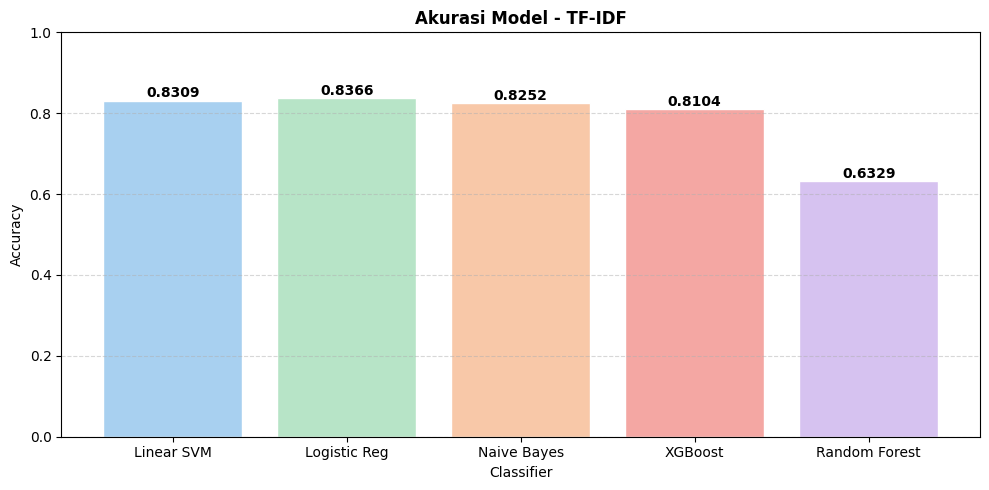

In [58]:
plt.figure(figsize=(10, 5))

names_tfidf = ['Linear SVM', 'Logistic Reg', 'Naive Bayes', 'XGBoost', 'Random Forest']
accs_tfidf  = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]
colors = ['#A8D0F0', '#B7E4C7', '#F8C8A8', '#F4A7A3', '#D6C2F0']
bars = plt.bar(names_tfidf, accs_tfidf, color=colors, edgecolor='white')

plt.title('Akurasi Model - TF-IDF', fontsize=12, fontweight='bold')
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, acc in zip(bars, accs_tfidf):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Universal Sentence Encoder (USE)
#### 1. Linear SVM
#### 2. Logistic Regression
#### 3. XGBoost classifier
#### 4. Random Forest classifier

### Load USE
Load the Universal Sentences Encoder model and embed this model

In [59]:
start = timer()
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print('Required time for upload USE from tensorflow hub:- ', timer() - start)

Required time for upload USE from tensorflow hub:-  13.152588860999913


In [60]:
xtrain_use = []
xtest_use = []

In [61]:
start = timer()
for i in range(0, len(xtrain), batch_size):
    batch_X_train = xtrain[i:i + batch_size]
    batch_X_train_use = np.array(embed(batch_X_train))
    xtrain_use.extend(batch_X_train_use)
print('Required time for embedding xtrain with USE:- ', timer() - start)

Required time for embedding xtrain with USE:-  1.6368682309998803


In [62]:
start = timer()
for i in range(0, len(xtest), batch_size):
    batch_X_test = xtest[i:i + batch_size]
    batch_X_test_use = np.array(embed(batch_X_test))
    xtest_use.extend(batch_X_test_use)
print('Required time for embedding xtest with USE:- ', timer() - start)

Required time for embedding xtest with USE:-  0.26348910299975614


### Fit Classifier

In [63]:
start = timer()
svm_use = svm_classifier.fit(xtrain_use, ytrain)
print('Required time for training Linear SVM classifier:- ', timer() - start)
start = timer()
lr_use = logistic_regression.fit(xtrain_use, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)
start = timer()
xgboost_use = xgboost_classifier.fit(xtrain_use, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start)
start = timer()
rfc_use = random_forest_classifier.fit(xtrain_use, ytrain)
print('Required time for training all Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM classifier:-  5.315878005999821
Required time for training Logistic Regression:-  5.693342426000072
Required time for training XGBoost classifier:-  60.34506603799991
Required time for training all Random Forest classifier:-  6.153038606000337


### Make Prediction

### Linear SVM

In [64]:
start = timer()
y_pred_svm_use, accuracy_svm_use, precision_svm_use, recall_svm_use, f1_svm_use, report_svm_use, cm_svm_use = evaluate_model(svm_use, xtest_use, ytest)
print('Required time for Linear SVM prediction with USE :- ', timer() - start)

Required time for Linear SVM prediction with USE :-  0.02875161100018886


In [65]:
# print actual vs predicted results for LinearSVM with USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_use[:15]):
    print(f"Actual: {actual}, SVM with USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 2

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 2, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 2



In [66]:
print(f"LinearSVM (USE) Accuracy: {accuracy_svm_use:.2f}")
print(f"LinearSVM (USE) Precision: {precision_svm_use:.2f}")
print(f"LinearSVM (USE) Recall: {recall_svm_use:.2f}")
print(f"LinearSVM (USE) F1 score: {f1_svm_use:.2f}")
print("Classification Report:")
print(report_svm_use)
print("Confusion Matrix")
print(cm_svm_use)

LinearSVM (USE) Accuracy: 0.83
LinearSVM (USE) Precision: 0.77
LinearSVM (USE) Recall: 0.83
LinearSVM (USE) F1 score: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85      1290
           1       0.00      0.00      0.00       188
           2       0.85      0.88      0.87      1148

    accuracy                           0.83      2626
   macro avg       0.55      0.59      0.57      2626
weighted avg       0.77      0.83      0.80      2626

Confusion Matrix
[[1168    3  119]
 [ 135    0   53]
 [ 140    2 1006]]


### Logistic Regression

In [67]:
start = timer()
y_pred_lr_use, accuracy_lr_use, precision_lr_use, recall_lr_use, f1_lr_use, report_lr_use, cm_lr_use = evaluate_model(lr_use, xtest_use, ytest)
print('Required time for LR prediction with USE :- ', timer() - start)

Required time for LR prediction with USE :-  0.031022553999719094


In [68]:
# print actual vs predicted results for Logistic Regression with USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_use[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted with USE: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 2

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 2, Logistic Regression Predicted with USE: 1

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 2, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 0, Logistic Regression Predicted with USE: 2



In [69]:
print(f"Logistic Regression (USE) Accuracy: {accuracy_lr_use:.2f}")
print(f"Logistic Regression (USE) Precision: {precision_lr_use:.2f}")
print(f"Logistic Regression (USE) Recall: {recall_lr_use:.2f}")
print(f"Logistic Regression (USE) F1 score: {f1_lr_use:.2f}")
print("Classification Report:")
print(report_lr_use)
print("Confusion Matrix")
print(cm_lr_use)

Logistic Regression (USE) Accuracy: 0.83
Logistic Regression (USE) Precision: 0.79
Logistic Regression (USE) Recall: 0.83
Logistic Regression (USE) F1 score: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85      1290
           1       0.18      0.01      0.02       188
           2       0.86      0.88      0.87      1148

    accuracy                           0.83      2626
   macro avg       0.62      0.60      0.58      2626
weighted avg       0.79      0.83      0.80      2626

Confusion Matrix
[[1170    5  115]
 [ 143    2   43]
 [ 138    4 1006]]


### XGBoost Classifier

In [70]:
start = timer()
y_pred_xgboost_use, accuracy_xgboost_use, precision_xgboost_use, recall_xgboost_use, f1_xgboost_use, report_xgboost_use, cm_xgboost_use = evaluate_model(xgboost_use, xtest_use, ytest)
print('Required time for XGBoost classifier prediction with USE:- ', timer() - start)

Required time for XGBoost classifier prediction with USE:-  0.06288389199971789


In [71]:
# print actual vs predicted results for XGBoost with USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost_use[:15]):
    print(f"Actual: {actual}, XGBoost with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 2

Actual: 2, XGBoost with USE Predicted: 2

Actual: 0, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 2, XGBoost with USE Predicted: 2

Actual: 2, XGBoost with USE Predicted: 2

Actual: 0, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 2, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 0, XGBoost with USE Predicted: 2



In [72]:
print(f"XGBoost (USE) Accuracy: {accuracy_xgboost_use:.2f}")
print(f"XGBoost (USE) Precision: {precision_xgboost_use:.2f}")
print(f"XGBoost (USE) Recall: {recall_xgboost_use:.2f}")
print(f"XGBoost (USE) F1 score: {f1_xgboost_use:.2f}")
print("Classification Report:")
print(report_xgboost_use)
print("Confusion Matrix:")
print(cm_xgboost_use)

XGBoost (USE) Accuracy: 0.83
XGBoost (USE) Precision: 0.80
XGBoost (USE) Recall: 0.83
XGBoost (USE) F1 score: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86      1290
           1       0.40      0.03      0.06       188
           2       0.87      0.85      0.86      1148

    accuracy                           0.83      2626
   macro avg       0.69      0.60      0.59      2626
weighted avg       0.80      0.83      0.80      2626

Confusion Matrix:
[[1186    6   98]
 [ 132    6   50]
 [ 164    3  981]]


### Random Forest Classifier

In [73]:
start = timer()
y_pred_rfc_use, accuracy_rfc_use, precision_rfc_use, recall_rfc_use, f1_rfc_use, report_rfc_use, cm_rfc_use = evaluate_model(rfc_use, xtest_use, ytest)
print('Required time for Random Forest classifier with USE prediction:- ', timer() - start)

Required time for Random Forest classifier with USE prediction:-  0.06199496699991869


In [74]:
#  print actual vs predicted results for Random Forest with USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_use[:15]):
    print(f"Actual: {actual}, Random Forest with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 2

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 2

Actual: 2, Random Forest with USE Predicted: 2

Actual: 0, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 2

Actual: 2, Random Forest with USE Predicted: 2

Actual: 2, Random Forest with USE Predicted: 2

Actual: 0, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 2

Actual: 2, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 2

Actual: 0, Random Forest with USE Predicted: 2



In [75]:
print(f"Random Forest (USE) Accuracy: {accuracy_rfc_use:.2f}")
print(f"Random Forest (USE) Precision: {precision_rfc_use:.2f}")
print(f"Random Forest (USE) Recall: {recall_rfc_use:.2f}")
print(f"Random Forest (USE) F1 score: {f1_rfc_use:.2f}")
print("Classification Report:")
print(report_rfc_use)
print("Confusion Matrix:")
print(cm_rfc_use)

Random Forest (USE) Accuracy: 0.80
Random Forest (USE) Precision: 0.76
Random Forest (USE) Recall: 0.80
Random Forest (USE) F1 score: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.94      0.83      1290
           1       0.00      0.00      0.00       188
           2       0.89      0.78      0.83      1148

    accuracy                           0.80      2626
   macro avg       0.55      0.57      0.55      2626
weighted avg       0.76      0.80      0.77      2626

Confusion Matrix:
[[1210    0   80]
 [ 160    0   28]
 [ 252    0  896]]


### Display All Four Models Accuracy

In [76]:
model_names = ['LinearSVM', 'LogisticRegression', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

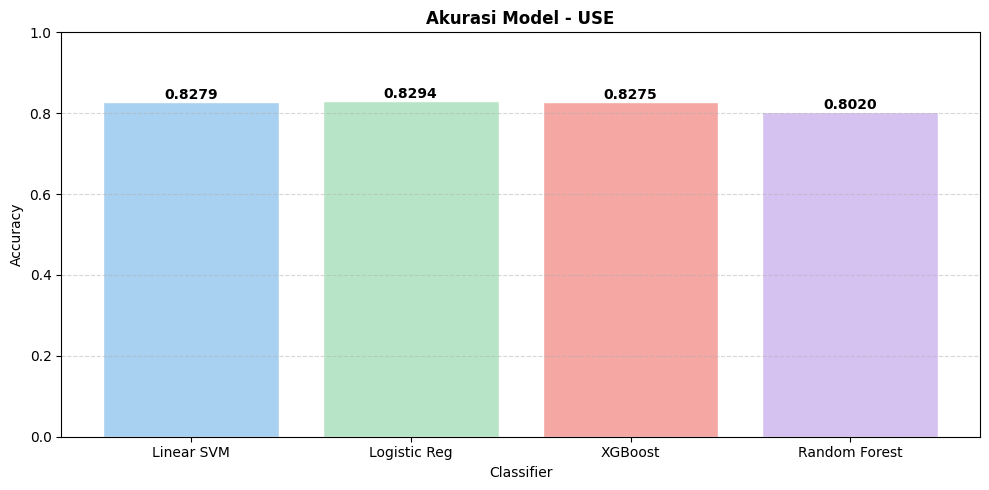

In [77]:
plt.figure(figsize=(10, 5))

names_use = ['Linear SVM', 'Logistic Reg', 'XGBoost', 'Random Forest']
accs_use  = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]
colors = ['#A8D0F0', '#B7E4C7', '#F4A7A3', '#D6C2F0']
bars = plt.bar(names_use, accs_use, color=colors, edgecolor='white')

plt.title('Akurasi Model - USE', fontsize=12, fontweight='bold')
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs_use):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. TF-IDF + Universal Sentence Encoder (USE)
#### 1. Linear SVM
#### 2. Logistic Regression
#### 3. XGBoost classifier
#### 4. Random Forest classifier

#### Combine TF-IDF and Universal Sentence Encoder embeddings


In [78]:
xtrain_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtrain, xtrain_use], axis=1)
xtest_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtest, xtest_use], axis=1)

#### Fit Classifier

In [79]:
start = timer()
svm_tfidf_use = svm_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Linear SVM:- ', timer() - start)
start = timer()
lr_tfidf_use = logistic_regression.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)
start = timer()
xgboost_tfidf_use = xgboost_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start)
start = timer()
rfc_tfidf_use = random_forest_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM:-  7.866264365000006
Required time for training Logistic Regression:-  16.089279103999615
Required time for training XGBoost classifier:-  107.7487581989999
Required time for training Random Forest classifier:-  6.915024851999988


#### Make Prediction

#### Linear SVM

In [80]:
start = timer()
y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, precision_svm_tfidf_use, recall_svm_tfidf_use, f1_svm_tfidf_use, report_svm_tfidf_use, cm_svm_tfidf_use = evaluate_model(svm_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Linear SVM prediction with TFIDF+USE :- ', timer() - start)

Required time for Linear SVM prediction with TFIDF+USE :-  0.06661580300033165


In [81]:
# print actual vs predicted results for Linear SVM with TFIDF + USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_tfidf_use[:15]):
    print(f"Actual: {actual}, SVM with TFIDF+USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 2

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 2, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 2, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 0, SVM with TFIDF+USE Predicted: 0



In [82]:
print(f"LinearSVM (TFIDF+USE) Accuracy: {accuracy_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Precision: {precision_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Recall: {recall_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) F1 score: {f1_svm_tfidf_use:.2f}")
print("Classification Report:")
print(report_svm_tfidf_use)
print("Confusion Matrix")
print(cm_svm_tfidf_use)

LinearSVM (TFIDF+USE) Accuracy: 0.83
LinearSVM (TFIDF+USE) Precision: 0.81
LinearSVM (TFIDF+USE) Recall: 0.83
LinearSVM (TFIDF+USE) F1 score: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1290
           1       0.32      0.11      0.17       188
           2       0.87      0.88      0.87      1148

    accuracy                           0.83      2626
   macro avg       0.67      0.63      0.63      2626
weighted avg       0.81      0.83      0.82      2626

Confusion Matrix
[[1155   30  105]
 [ 119   21   48]
 [ 126   15 1007]]


#### Logistic Regression

In [83]:
start = timer()
y_pred_lr_tfidf_use, accuracy_lr_tfidf_use, precision_lr_tfidf_use, recall_lr_tfidf_use, f1_lr_tfidf_use, report_lr_tfidf_use, cm_lr_tfidf_use = evaluate_model(lr_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Logistic Regression prediction with TFIDF+USE :- ', timer() - start)

Required time for Logistic Regression prediction with TFIDF+USE :-  0.05966722099992694


In [84]:
# print actual vs predicted results for Logistic Regression with TFIDF + USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_tfidf_use[:15]):
    print(f"Actual: {actual}, LR with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 2

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 2, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 2, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 0, LR with TFIDF+USE embedding Predicted: 0



In [85]:
print(f"Logistic Regression (TFIDF+USE) Accuracy: {accuracy_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Precision: {precision_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Recall: {recall_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) F1 score: {f1_lr_tfidf_use:.2f}")
print("Classification Report:")
print(report_lr_tfidf_use)
print("Confusion Matrix")
print(cm_lr_tfidf_use)

Logistic Regression (TFIDF+USE) Accuracy: 0.84
Logistic Regression (TFIDF+USE) Precision: 0.81
Logistic Regression (TFIDF+USE) Recall: 0.84
Logistic Regression (TFIDF+USE) F1 score: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1290
           1       0.26      0.04      0.07       188
           2       0.88      0.88      0.88      1148

    accuracy                           0.84      2626
   macro avg       0.66      0.62      0.61      2626
weighted avg       0.81      0.84      0.82      2626

Confusion Matrix
[[1194   11   85]
 [ 131    7   50]
 [ 125    9 1014]]


XGBoost Classifier

In [86]:
start = timer()
y_pred_xgb_tfidf_use, accuracy_xgb_tfidf_use, precision_xgb_tfidf_use, recall_xgb_tfidf_use, f1_xgb_tfidf_use, report_xgb_tfidf_use, cm_xgb_tfidf_use = evaluate_model(xgboost_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for XGBoost prediction with TFIDF+USE :- ', timer() - start)

Required time for XGBoost prediction with TFIDF+USE :-  0.3752119400000993


In [87]:
# print actual vs predicted results for XGBoost with TFIDF + USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgb_tfidf_use[:15]):
    print(f"Actual: {actual}, XGBoost with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 2



In [88]:
print(f"XGBoost (TFIDF+USE) Accuracy: {accuracy_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Precision: {precision_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Recall: {recall_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) F1 score: {f1_xgb_tfidf_use:.2f}")
print("Classification Report:")
print(report_xgb_tfidf_use)
print("Confusion Matrix:")
print(cm_xgb_tfidf_use)

XGBoost (TFIDF+USE) Accuracy: 0.84
XGBoost (TFIDF+USE) Precision: 0.81
XGBoost (TFIDF+USE) Recall: 0.84
XGBoost (TFIDF+USE) F1 score: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1290
           1       0.33      0.03      0.06       188
           2       0.88      0.87      0.87      1148

    accuracy                           0.84      2626
   macro avg       0.67      0.61      0.60      2626
weighted avg       0.81      0.84      0.81      2626

Confusion Matrix:
[[1196    6   88]
 [ 129    6   53]
 [ 146    6  996]]


#### Random Forest Classifier

In [89]:
start = timer()
y_pred_rfc_tfidf_use, accuracy_rfc_tfidf_use, precision_rfc_tfidf_use, recall_rfc_tfidf_use, f1_rfc_tfidf_use, report_rfc_tfidf_use, cm_rfc_tfidf_use = evaluate_model(rfc_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Random Forest prediction with TFIDF+USE :- ', timer() - start)

Required time for Random Forest prediction with TFIDF+USE :-  0.09387337599991952


In [90]:
# print actual vs predicted results for Random Forest with TFIDF + USE
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_tfidf_use[:15]):
    print(f"Actual: {actual}, RFC with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 2, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 2, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 2

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0



In [91]:
print(f"Random Forest (TFIDF+USE) Accuracy: {accuracy_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Precision: {precision_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Recall: {recall_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) F1 score: {f1_rfc_tfidf_use:.2f}")
print("Classification Report:")
print(report_rfc_tfidf_use)
print("Confusion Matrix:")
print(cm_rfc_tfidf_use)

Random Forest (TFIDF+USE) Accuracy: 0.79
Random Forest (TFIDF+USE) Precision: 0.75
Random Forest (TFIDF+USE) Recall: 0.79
Random Forest (TFIDF+USE) F1 score: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.96      0.82      1290
           1       0.00      0.00      0.00       188
           2       0.91      0.73      0.81      1148

    accuracy                           0.79      2626
   macro avg       0.54      0.56      0.54      2626
weighted avg       0.75      0.79      0.76      2626

Confusion Matrix:
[[1234    0   56]
 [ 157    0   31]
 [ 314    0  834]]


#### Visualization

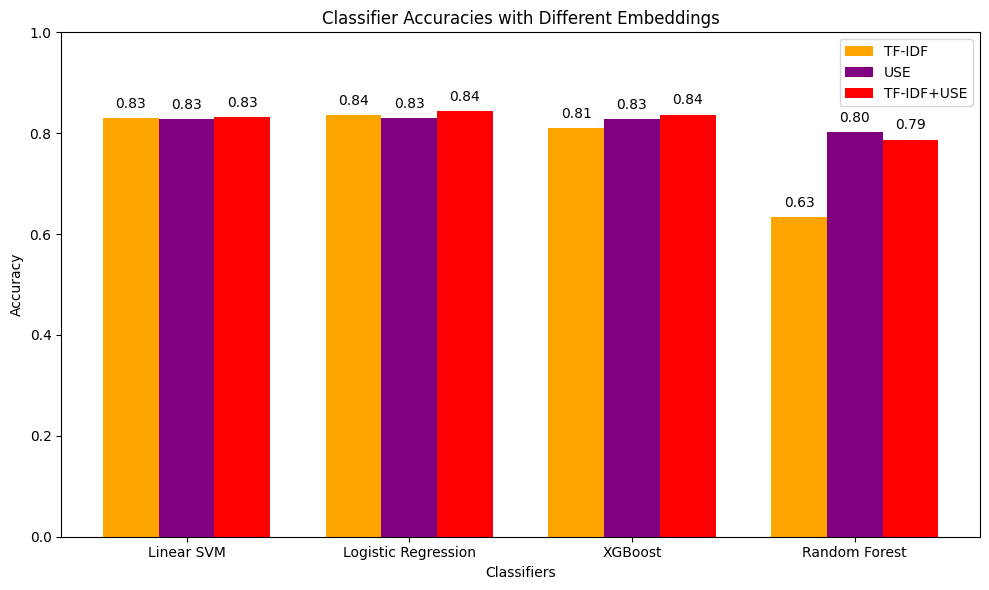

In [92]:
# Define the classifiers and their corresponding accuracies
classifiers = ["Linear SVM", "Logistic Regression", "XGBoost", "Random Forest"]
tfidf_accuracies = [accuracy_svm, accuracy_lr, accuracy_xgboost, accuracy_rfc]  # Replace with actual accuracy values
use_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]  # Replace with actual accuracy values
tfidf_use_accuracies = [accuracy_svm_tfidf_use, accuracy_lr_tfidf_use, accuracy_xgb_tfidf_use, accuracy_rfc_tfidf_use]  # Replace with actual accuracy values

# Create an index for the x-axis
x = np.arange(len(classifiers))

# Set the width of the bars
bar_width = 0.25

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, tfidf_accuracies, bar_width, label='TF-IDF', color='orange')
plt.bar(x, use_accuracies, bar_width, label='USE', color='purple')
plt.bar(x + bar_width, tfidf_use_accuracies, bar_width, label='TF-IDF+USE', color='red')

# Set labels, title, and legend
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings')
plt.xticks(x, classifiers)
plt.ylim(0, 1.0)
plt.legend()

# Add accuracy values on top of the bars
for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accuracies[i] + 0.02, f"{tfidf_accuracies[i]:.2f}", ha='center')
    plt.text(x[i], use_accuracies[i] + 0.02, f"{use_accuracies[i]:.2f}", ha='center')
    plt.text(x[i] + bar_width, tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center')


# Display the plot
plt.tight_layout()
plt.show()
